# Lab 3: Digital Modulation, Pulse Shaping, Matched Filtering, and Detection
Name: Marc Pham

# Lab 3 Task 1: Modulation, Detection, and Error Rate

In [12]:
from pathlib import Path
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def locate_lab_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "support" / "lab3_tools.py").is_file():
            return base
    raise FileNotFoundError("Open this notebook from its Lab 3 folder.")

LAB_ROOT = locate_lab_root()
sys.path.insert(0, str(LAB_ROOT / "support"))
WORK_DIR = LAB_ROOT / "work"
FIGURE_DIR = WORK_DIR / "figures"
WAVEFORM_DIR = WORK_DIR / "waveforms"
CAPTURE_DIR = WORK_DIR / "captures"
for path in (FIGURE_DIR, WAVEFORM_DIR, CAPTURE_DIR):
    path.mkdir(parents=True, exist_ok=True)
print("Lab root:", LAB_ROOT)

Lab root: /Users/marcpham/jupyter_notebook_files/Embedded-Wireless-Design-Labs/Lab3


<span style="color:#165696"><b>Answer in the report.</b> State the input and output of the constellation, detector, AWGN, theory, simulation, and plotting stages / functions in one sentence each.</span>

The PSK constellation function (psk_constellation) has an input of the modulation order M and an output of a unit-energy Gray-coded PSK constellation containing M complex symbols.

The square-QAM constellation function (square_qam_constellation) has an input of the modulation order M and an output of a Gray-coded square-QAM constellation normalized to unit average symbol energy.

The minimum-distance detector function (minimum_distance_detector) has inputs of the received complex symbols and the reference constellation and an output of the detected symbol labels corresponding to the nearest constellation points.

The PSK theory function (psk_theory_from_ebn0) has inputs of the modulation order M and Eb/N0 values in dB and an output of the theoretical PSK symbol error rate for each Eb/N0 value.

The QAM theory function (qam_theory_from_ebn0) has inputs of the modulation order M and Eb/N0 values in dB and an output of the theoretical square-QAM symbol error rate for each Eb/N0 value.

The AWGN channel function has inputs of the transmitted symbols and the desired Eb/N0 value and an output of received symbols corrupted by complex additive white Gaussian noise.

The simulation function (simulate_awgn_point) has inputs of the constellation, detector, channel parameters, and simulation settings and an output of the measured symbol error rate and other simulation statistics for a specified Eb/N0.

The plotting function (plot_error_rate_results) has inputs of the theoretical and simulated symbol error rate data and an output of an SER versus Eb/N0 performance plot.

The constellation plotting function (plot_constellation_snapshots) has inputs of constellation and simulation data and an output of constellation diagrams showing the transmitted and received symbol distributions.

## PSK mapping, detector, and theory

In [3]:
from scipy import integrate, special
from lab3_dsp import gray_decode, integers_to_bits
from lab3_tools import simulate_awgn_point, plot_error_rate_results, plot_constellation_snapshots

def psk_constellation(order):
    labels = np.arange(order, dtype=np.int64)
    # To Do: map Gray labels to physical phase indices.
    phase_index = gray_decode(labels)
    # To Do: return the unit-energy PSK points.
    return np.exp(1j * 2 * np.pi * phase_index / order)

def minimum_distance_detector(received, constellation):
    # To Do: calculate squared Euclidean distance to every point.
    distance_squared = np.abs(received[:, None] - constellation[None, :])**2
    # To Do: return the closest constellation index for each sample.
    return np.argmin(distance_squared, axis=1)

def psk_theory_from_ebn0(order, ebn0_db):
    bits_per_symbol = int(np.log2(order))
    # To Do: convert Eb/N0 in dB to linear Es/N0.
    gamma_s = bits_per_symbol * (10**(np.asarray(ebn0_db) / 10))
    upper = (order - 1) * np.pi / order
    values = []
    for value in np.atleast_1d(gamma_s):
        coefficient = value * np.sin(np.pi / order)**2
        def integrand(theta):
            sine = np.sin(theta)
            return 0.0 if abs(sine) < 1e-14 else np.exp(-coefficient / sine**2)
        # To Do: evaluate the coherent M-PSK integral.
        values.append((integrate.quad(integrand, 0, upper)[0]) / np.pi)
    return np.asarray(values)

<span style="color:#165696"><b>Answer in the report.</b> Check the length, average energy, and modulated values for the known label sequence [0, 1, 2, 3] when M = 4.</span>

The PSK constellation for M=4 was verified to have a length of 4 symbols with an average symbol energy of 1. The known label sequence [0,1,2,3] was mapped to the complex symbols [1+0j,  0+1j,  0−1j,  −1+0j], confirming correct Gray-coded modulation.

In [16]:
order = 4
print(f"Order {order}")
print(f"Length: {points.size}")
print(f"Average energy: {np.mean(np.abs(points)**2)}")
print(f"Modulated Values: {np.round(points, 3)}")
points = np.asarray(psk_constellation(order))
assert points.size == order
assert np.isclose(np.mean(np.abs(points)**2), 1.0)
assert np.array_equal(minimum_distance_detector(points, points), np.arange(order))
print(f"PSK geometry and noiseless detection passed for Order {order}.")

Order 4
Length: 4
Average energy: 1.0
Modulated Values: [ 1.+0.j  0.+1.j -0.-1.j -1.+0.j]
PSK geometry and noiseless detection passed for Order 4.


<span style="color:#165696"><b>Answer in the report.</b> Verify the average energy of every PSK constellation.</span>

In [14]:
for order in (2, 4, 8, 16, 32):
    points = np.asarray(psk_constellation(order))
    assert points.size == order
    assert np.isclose(np.mean(np.abs(points)**2), 1.0)
    assert np.array_equal(minimum_distance_detector(points, points), np.arange(order))
    if (order == 4):
        print(f"Order {order}")
        print(f"Length: {points.size}")
        print(f"Average energy: {np.mean(np.abs(points)**2)}")
        print(f"Modulated Values: {np.round(points, 3)}")
print("PSK geometry and noiseless detection passed.")

Order 4
Length: 4
Average energy: 1.0
Modulated Values: [ 1.+0.j  0.+1.j -0.-1.j -1.+0.j]
PSK geometry and noiseless detection passed.


<span style="color:#165696"><b>Answer in the report.</b> Add complex AWGN at one moderate Eb/N0 value. Print the converted Es/N0, N0, the
number of symbol errors, and the measured SER. This single-point test checks the noise
convention before the sweep.</span>


In [13]:
order = 4
ebn0_db = 6.0

rng = np.random.default_rng(7377)
result = simulate_awgn_point(
    psk_constellation(order),
    ebn0_db,
    rng,
    minimum_distance_detector
)

df = pd.DataFrame([result])
display(df)

,ebn0_db,esn0_db,symbols,symbol_errors,bit_errors,ser,ber,zero_error_95_percent_upper_bound
0,6.0,9.0103,50000,247,248,0.00494,0.00248,0.00006


<span style="color:#165696"><b>Answer in the report.</b> Compare the
simulated SER markers with theory. Compare theory and simulation. </span>

The simulated SER markers closely match the theoretical SER curves for all PSK modulation orders, demonstrating good agreement between the Monte Carlo simulation and the analytical results. Small differences between the markers and curves are due to the finite number of simulated symbols and the randomness of the noise samples. Overall, the close overlap between theory and simulation confirms the correctness of the modulation, detection, and AWGN implementations.

<span style="color:#165696"><b>Answer in the report.</b> Explain the effect of M on minimum distance, spectral
efficiency, and required Eb/N0. Compare modulation orders. </span>

As the modulation order M increases from 2-PSK to 32-PSK, the minimum distance between constellation points decreases, making the symbols more susceptible to noise and increasing the SER at a given Eb/N0. Higher modulation orders provide greater spectral efficiency because each symbol carries more bits, but they require a higher Eb/N0 to achieve the same error performance as lower-order PSK schemes. As shown in the results, 2-PSK and 4-PSK achieve the lowest SER, while 16-PSK and 32-PSK exhibit significantly higher error rates over the same Eb/N0 range.

<span style="color:#165696"><b>Answer in the report.</b> For any operating point without a marker, report the number of simulated symbols and errors and explain why the Monte Carlo result is not precise enough to plot. </span>

At Eb/N0=10 dB, the 2-PSK and 4-PSK simulations produced very few symbol errors despite transmitting 2,000,000 symbols. Specifically, 2-PSK resulted in 4 symbol errors ($\text{SER}=2\times10^{-6}$) and 4-PSK resulted in 15 symbol errors ($\text{SER}=8\times10^{-6}$), indicating that the error-rate estimates are based on a very small number of observed errors. Because Monte Carlo accuracy depends on collecting a sufficiently large error count, these operating points have higher statistical uncertainty, making the measured SER less precise than points with hundreds or thousands of observed errors.

In [27]:
for order in (2, 4):
    df = pd.DataFrame(psk_results[order])
    print(f"\n{order}-PSK")
    display(df)


2-PSK


,ebn0_db,esn0_db,symbols,symbol_errors,bit_errors,ser,ber,zero_error_95_percent_upper_bound
0,-4.0,-4.0,50000,9460,9460,0.189200,0.189200,0.000060
1,-2.0,-2.0,50000,6586,6586,0.131720,0.131720,0.000060
2,0.0,0.0,50000,4027,4027,0.080540,0.080540,0.000060
3,2.0,2.0,50000,1899,1899,0.037980,0.037980,0.000060
4,4.0,4.0,50000,584,584,0.011680,0.011680,0.000060
5,6.0,6.0,100000,246,246,0.002460,0.002460,0.000030
6,8.0,8.0,1000000,204,204,0.000204,0.000204,0.000003
7,10.0,10.0,2000000,4,4,0.000002,0.000002,0.000002



4-PSK


,ebn0_db,esn0_db,symbols,symbol_errors,bit_errors,ser,ber,zero_error_95_percent_upper_bound
0,-4.0,-0.9897,50000,16752,18499,0.335040,0.184990,0.000060
1,-2.0,1.0103,50000,12236,13111,0.244720,0.131110,0.000060
2,0.0,3.0103,50000,7469,7757,0.149380,0.077570,0.000060
3,2.0,5.0103,50000,3683,3752,0.073660,0.037520,0.000060
4,4.0,7.0103,50000,1275,1285,0.025500,0.012850,0.000060
5,6.0,9.0103,50000,217,217,0.004340,0.002170,0.000060
6,8.0,11.0103,550000,225,225,0.000409,0.000205,0.000005
7,10.0,13.0103,2000000,15,15,0.000008,0.000004,0.000002


<span style="color:#165696"><b>Answer in the report.</b> Explain why SER and BER are not interchangeable. Explain why SER and BER are different. </span>

SER and BER are not interchangeable because SER measures the probability of detecting an entire symbol incorrectly, while BER measures the probability of detecting an individual bit incorrectly. In M-PSK, each symbol represents multiple bits, so a single symbol error may cause one or more bit errors depending on the detected symbol. With Gray coding, most symbol errors occur between adjacent symbols and typically result in only one bit error, making the BER lower than the SER.

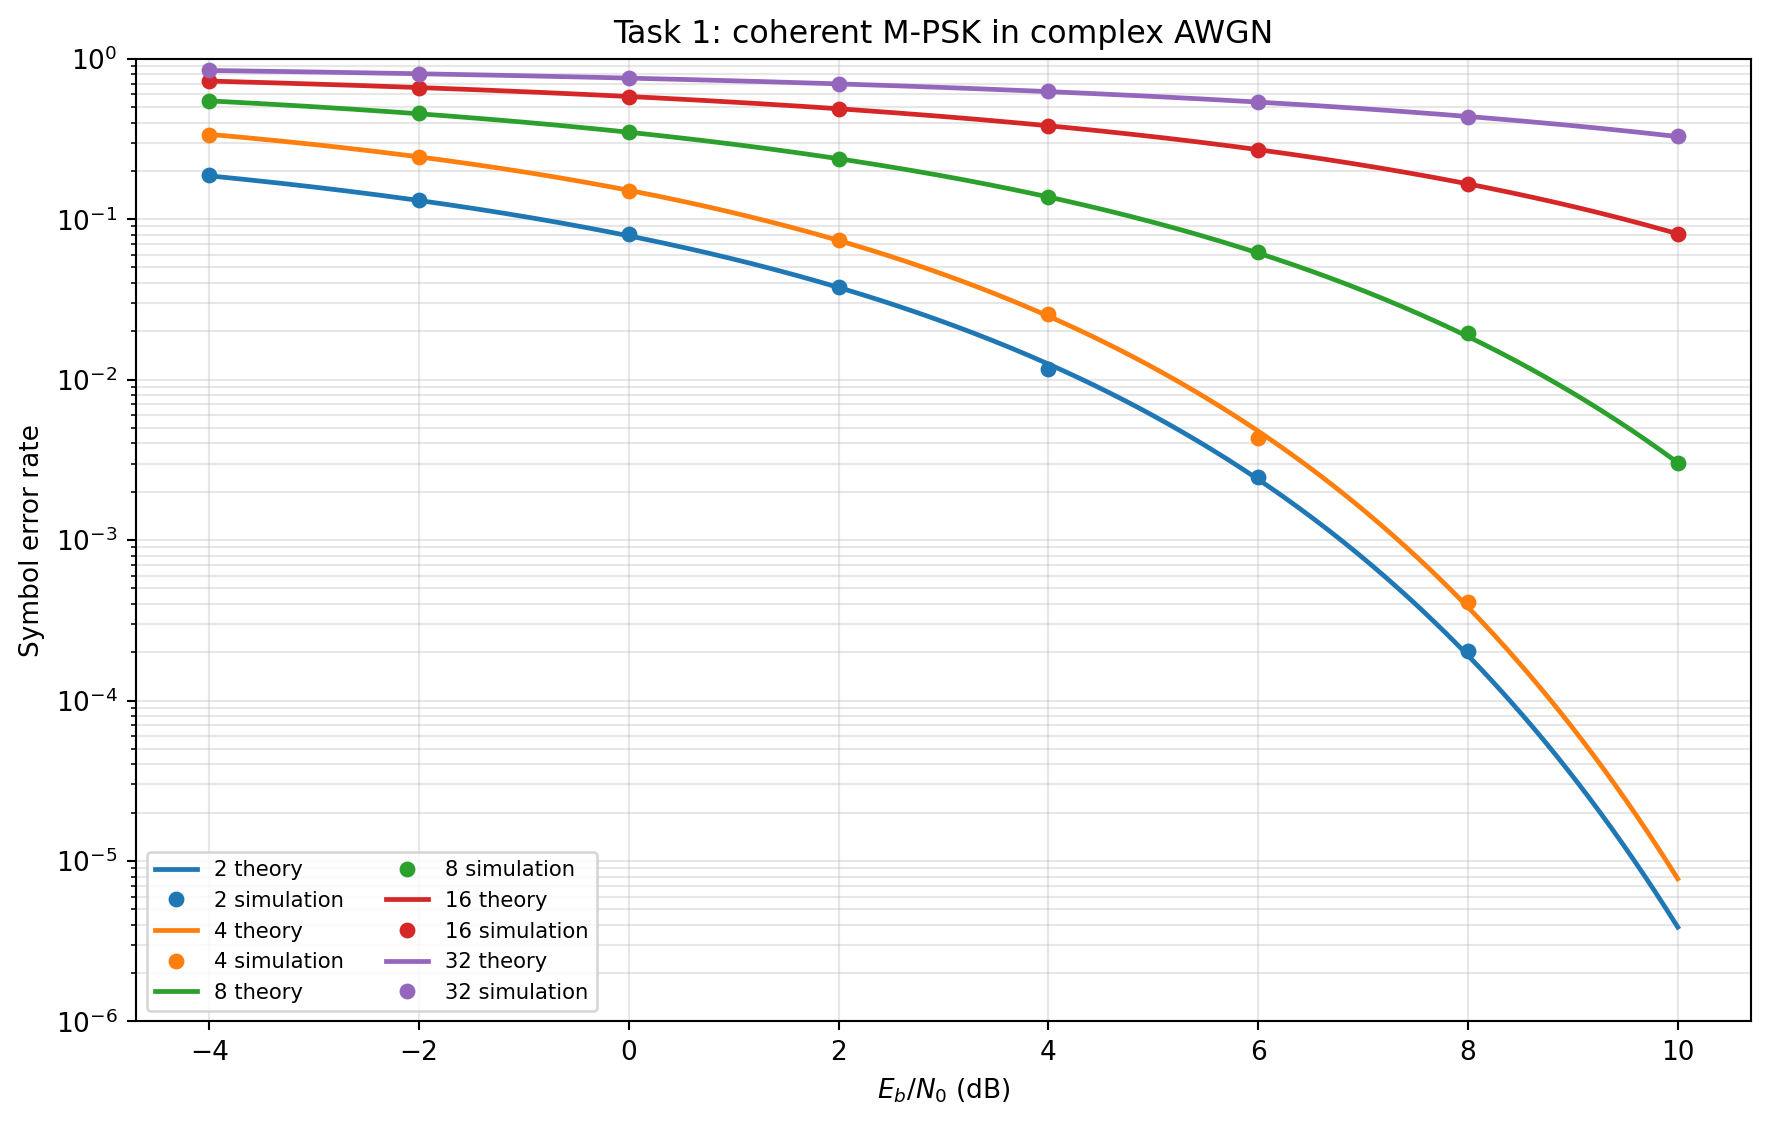

In [18]:
rng = np.random.default_rng(7377)
psk_results = {}
for order in (2, 4, 8, 16, 32):
    constellation = psk_constellation(order)
    psk_results[order] = [
        simulate_awgn_point(constellation, ebn0, rng, minimum_distance_detector)
        for ebn0 in np.arange(-4.0, 10.1, 2.0)
    ]
psk_figure = plot_error_rate_results(
    psk_results, psk_theory_from_ebn0,
    "Task 1: coherent M-PSK in complex AWGN",
    FIGURE_DIR, "task1_psk_error_rates"
)
display(Image(filename=str(psk_figure)))

## Square QAM mapping and theory

In [28]:
def square_qam_constellation(order):
    side = int(np.sqrt(order))
    axis_bits = int(np.log2(side))
    labels = np.arange(order, dtype=np.int64)
    i_labels = labels >> axis_bits
    q_labels = labels & (side - 1)
    levels = 2*np.arange(side) - (side - 1)
    # To Do: Gray map each axis and form the complex grid.
    points = levels[gray_decode(i_labels)] + 1j * levels[gray_decode(q_labels)]
    # To Do: normalize the complete constellation to unit average energy.
    return points / np.sqrt(np.mean(np.abs(points)**2))

def qam_theory_from_ebn0(order, ebn0_db):
    bits_per_symbol = int(np.log2(order))
    # To Do: convert Eb/N0 to linear Es/N0.
    gamma_s = bits_per_symbol * 10**(np.array(ebn0_db) / 10.0)
    # To Do: evaluate Q(x) and the square-QAM SER expression.
    q_value = 0.5 * special.erfc((np.sqrt(3 * gamma_s / (order - 1)) / np.sqrt(2)))
    return 1 - (1 - 2 * (1 - 1 / np.sqrt(order)) * q_value)**2

<span style="color:#165696"><b>Answer in the report.</b> Verify the average energy of 16-, 64-, and 256-QAM. </span>

In [29]:
for order in (16, 64, 256):
    points = np.asarray(square_qam_constellation(order))
    assert points.size == order
    assert np.isclose(np.mean(np.abs(points)**2), 1.0)
    assert np.array_equal(minimum_distance_detector(points, points), np.arange(order))
print("QAM geometry and noiseless detection passed.")

QAM geometry and noiseless detection passed.


<span style="color:#165696"><b>Answer in the report.</b> Compare theory and
simulated SER, then tabulate both SER and BER at two selected operating points (8.0 dB and 16 dB).</span>

The simulated SER closely matches the theoretical SER curves for 16-QAM, 64-QAM, and 256-QAM across the tested Eb/N0 range. Small differences between the simulation markers and theoretical curves are due to finite Monte Carlo sampling and random noise realizations. Overall, the agreement between theory and simulation confirms the correctness of the QAM modulator, detector, and AWGN implementation.

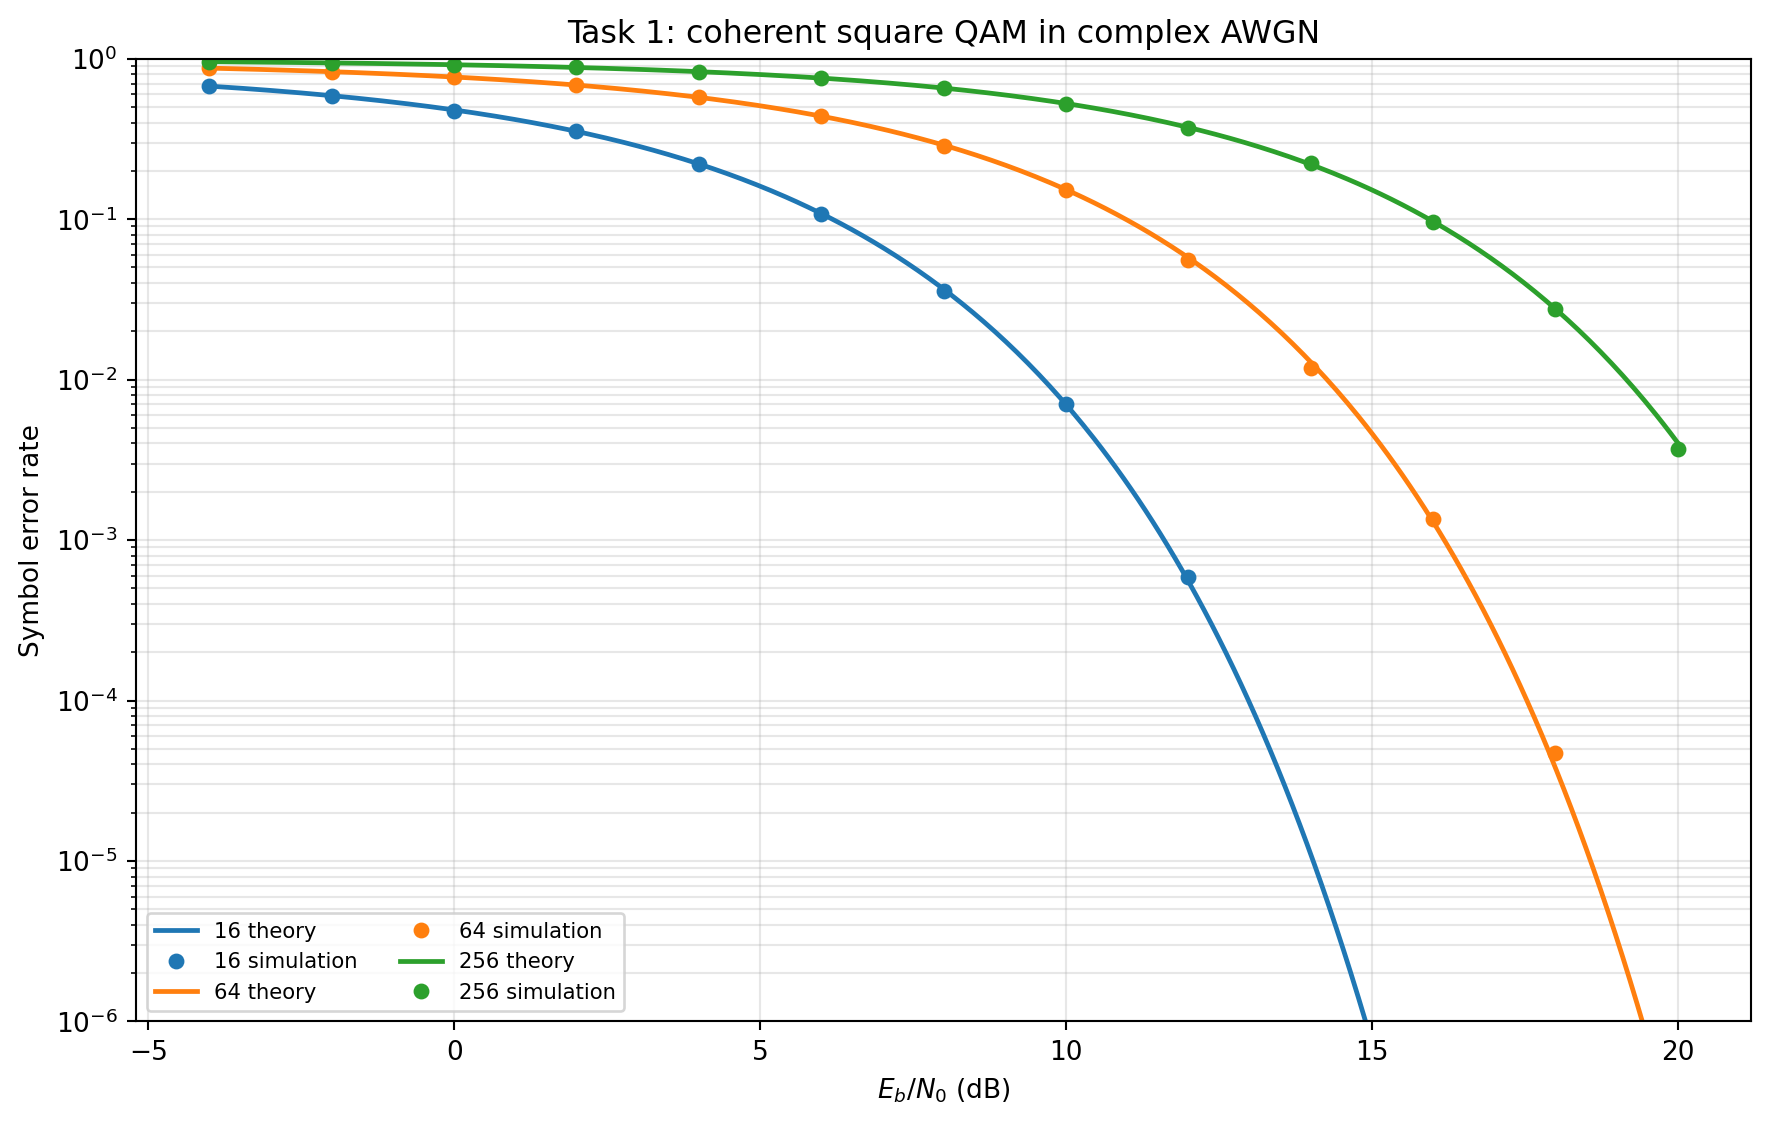

In [32]:
rng = np.random.default_rng(7378)
qam_results = {}
for order in (16, 64, 256):
    constellation = square_qam_constellation(order)
    qam_results[order] = [
        simulate_awgn_point(constellation, ebn0, rng, minimum_distance_detector)
        for ebn0 in np.arange(-4.0, 20.1, 2.0)
    ]
qam_figure = plot_error_rate_results(
    qam_results, qam_theory_from_ebn0,
    "Task 1: coherent square QAM in complex AWGN",
    FIGURE_DIR, "task1_qam_error_rates"
)
display(Image(filename=str(qam_figure)))

In [33]:
selected_rows = []

for order in (16, 64, 256):
    df = pd.DataFrame(qam_results[order])
    selected_rows.append(
        df[df["ebn0_db"] == 8.0][["ebn0_db", "ser", "ber"]]
        .assign(modulation=f"{order}-QAM")
    )
    selected_rows.append(
        df[df["ebn0_db"] == 16.0][["ebn0_db", "ser", "ber"]]
        .assign(modulation=f"{order}-QAM")
    )
report_table = pd.concat(selected_rows, ignore_index=True)

# reorder columns
report_table = report_table[
    ["modulation", "ebn0_db", "ser", "ber"]
]

display(report_table)

,modulation,ebn0_db,ser,ber
0,16-QAM,8.0,0.035460,0.008910
1,16-QAM,16.0,0.000000,0.000000
2,64-QAM,8.0,0.287360,0.051963
3,64-QAM,16.0,0.001353,0.000226
4,256-QAM,8.0,0.653080,0.107493
5,256-QAM,16.0,0.096340,0.012382


<span style="color:#165696"><b>Answer in the report.</b> Explain how
modulation order changes the Eb/N0 required for a target SER. Compare modulation orders</span>

As the modulation order increases, the required Eb/N0 for a target SER also increases. Higher-order QAM constellations have more closely spaced symbols, making them more susceptible to noise and increasing the probability of symbol errors. Consequently, 64-QAM and 256-QAM require significantly higher Eb/N0 values than 16-QAM to achieve the same SER performance.

<span style="color:#165696"><b>Answer in the report.</b> At 12 dB Es/N0, compare the noisy
QPSK, 8-PSK, and 16-QAM clusters and relate their spread to the nearest decision boundaries.</span>

At 12 dB Es/N0, the QPSK clusters are tightly grouped around their constellation points and remain well separated from the nearest decision boundaries, resulting in a low probability of symbol error. The 8-PSK clusters exhibit a similar noise spread, but the constellation points are closer together, placing more samples near the decision boundaries and increasing the likelihood of detection errors. The 16-QAM clusters are separated by the smallest minimum distance, causing many noisy samples to lie closer to neighboring decision regions, making 16-QAM the most sensitive to noise among the three modulation schemes.

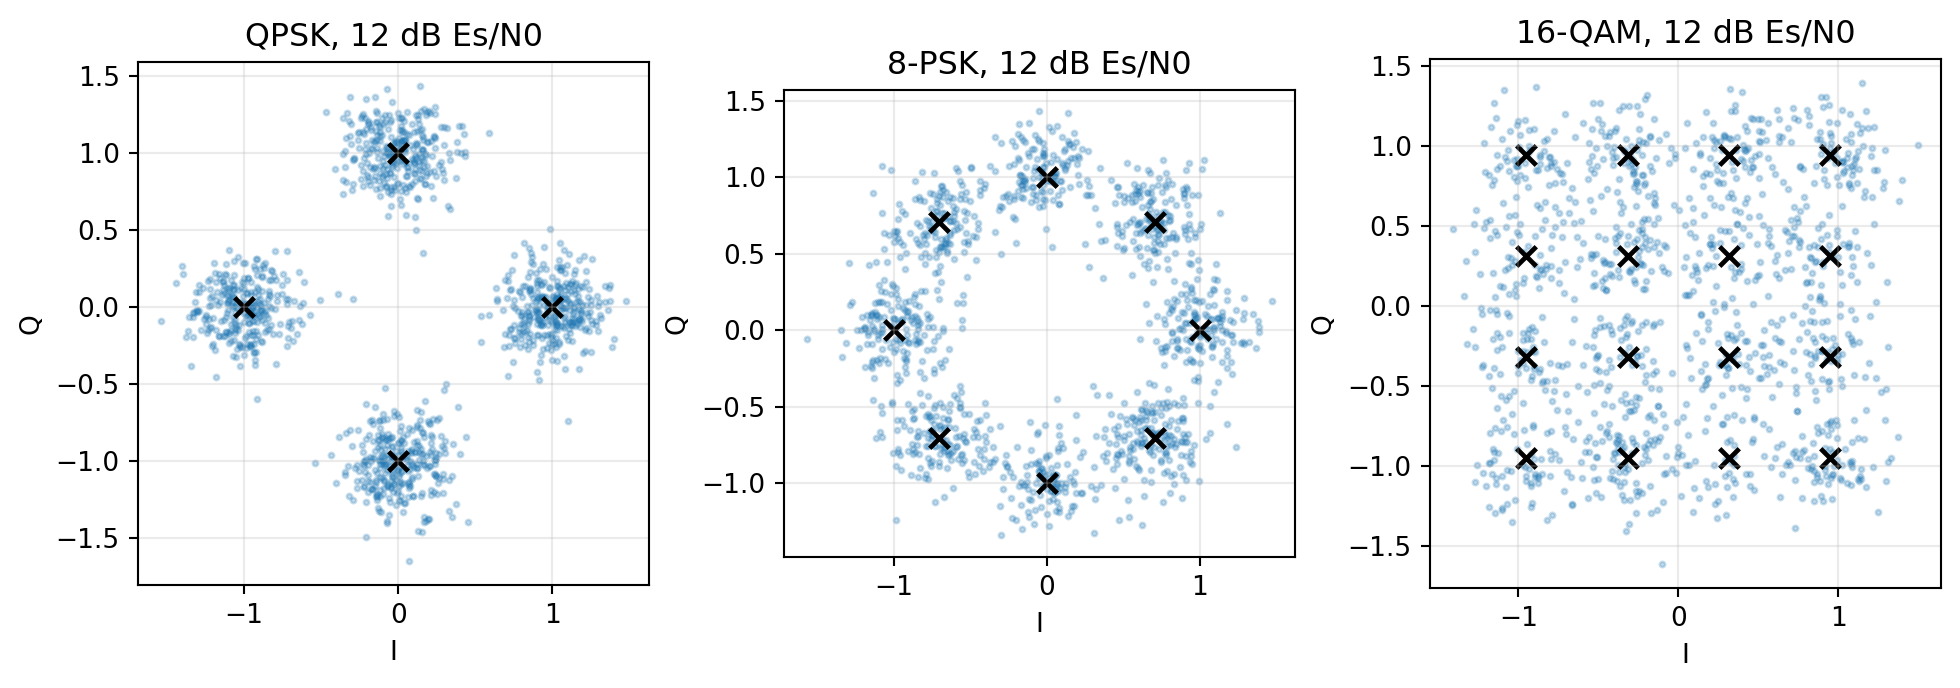

In [7]:
rng = np.random.default_rng(7379)
snapshots = []
for name, points in (
    ("QPSK, 12 dB Es/N0", psk_constellation(4)),
    ("8-PSK, 12 dB Es/N0", psk_constellation(8)),
    ("16-QAM, 12 dB Es/N0", square_qam_constellation(16)),
):
    labels = rng.integers(0, len(points), 1200)
    n0 = 10**(-12/10)
    noise = np.sqrt(n0/2)*(rng.standard_normal(labels.size) + 1j*rng.standard_normal(labels.size))
    snapshots.append((name, points[labels] + noise, points))
constellation_figure = plot_constellation_snapshots(snapshots, FIGURE_DIR)
display(Image(filename=str(constellation_figure)))

# Lab 3 Task 2: 4-PAM Pulse Shaping and Matched Filtering

In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def locate_lab_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "support" / "lab3_tools.py").is_file():
            return base
    raise FileNotFoundError("Open this notebook from its Lab 3 folder.")

LAB_ROOT = locate_lab_root()
sys.path.insert(0, str(LAB_ROOT / "support"))
WORK_DIR = LAB_ROOT / "work"
FIGURE_DIR = WORK_DIR / "figures"
WAVEFORM_DIR = WORK_DIR / "waveforms"
CAPTURE_DIR = WORK_DIR / "captures"
for path in (FIGURE_DIR, WAVEFORM_DIR, CAPTURE_DIR):
    path.mkdir(parents=True, exist_ok=True)
print("Lab root:", LAB_ROOT)

Lab root: /Users/marcpham/jupyter_notebook_files/Embedded-Wireless-Design-Labs/Lab3


In [3]:
from scipy import special
from lab3_dsp import rrc_taps
from lab3_tools import plot_pam_chain, plot_pam_eye

order = 4
symbol_count = 20_000
samples_per_symbol = 4
rolloff = 0.35
span_symbols = 10
ebn0_db = 10.0
rng = np.random.default_rng(303)
labels = rng.integers(0, order, symbol_count)

# To Do: normalized 4-PAM levels indexed by labels 0, 1, 2, 3.
levels = (2 * np.arange(order) - 3) / np.sqrt(5)
symbols = levels[labels]

# To Do: insert L-1 zeros between adjacent symbols.
upsampled = np.zeros(symbol_count * samples_per_symbol)
upsampled[::samples_per_symbol] = symbols

taps = rrc_taps(rolloff, samples_per_symbol, span_symbols)
transmitted = np.convolve(upsampled, taps)

bits_per_symbol = int(np.log2(order))
gamma_b = 10**(ebn0_db/10)
# To Do: derive Eb, N0, and the real noise variance.
symbol_energy = 1.0
bit_energy = symbol_energy / bits_per_symbol
n0 = bit_energy / gamma_b
noise_variance = n0 / 2

received = transmitted + rng.normal(0, np.sqrt(noise_variance), transmitted.size)
matched = np.convolve(received, taps)

# To Do: derive the two-filter delay and correct decision indices.
one_filter_delay = (len(taps) - 1) // 2
cascade_delay = 2 * one_filter_delay
decision_indices = (cascade_delay + np.arange(symbol_count) * samples_per_symbol)
decisions = matched[decision_indices]

# To Do: nearest-level detection, SER, and RMS EVM.
detected = np.argmin(np.abs(decisions[:, None] - levels[None, :])**2, axis=1)
ser = np.mean(detected != labels)
evm = np.sqrt(np.sum(np.abs(decisions - symbols)**2) / np.sum(np.abs(symbols)**2))

<span style="color:#165696"><b>Answer in the report.</b> Show the 4-PAM energy, zero-insertion operation, both filter delays, Eb, N0, noise variance, measured and theoretical SER, and RMS EVM.</span>

In [12]:
assert np.isclose(np.mean(levels**2), 1.0)
assert len(taps) == 41
assert cascade_delay == 40
assert np.isclose(noise_variance, 0.025)
argument = np.sqrt(6*bits_per_symbol*gamma_b/(order**2 - 1))
theoretical_ser = 2*(order-1)/order * 0.5*special.erfc(argument/np.sqrt(2))

print("===== Task 2 Results =====\n")

# 4-PAM energy
print(f"4-PAM Levels: {levels}")
print(f"4-PAM Average Symbol Energy (Es): {np.mean(levels**2):.3f}")

# Zero insertion
print(f"\nZero-Insertion Operation")
print(f"Original symbol count: {len(symbols)}")
print(f"Upsampled sequence length: {len(upsampled)}")
print("First 16 upsampled samples:")
print(np.round(upsampled[:16], 3))

# Filter delays
print(f"\nBoth Filter Delays")
print(f"RRC filter length: {len(taps)}")
print(f"One-filter delay: {one_filter_delay} samples")
print(f"Cascade delay: {cascade_delay} samples")

# Noise parameters
print(f"\nBits per symbol (k): {bits_per_symbol}")
print(f"Eb/N0: {ebn0_db:.1f} dB")
print(f"Eb: {bit_energy:.4f}")
print(f"N0: {n0:.4f}")
print(f"Noise variance: {noise_variance:.4f}")

# Performance metrics
print(f"SER measured/theory: {ser:.6f} / {theoretical_ser:.6f}")
print(f"RMS EVM: {100*evm:.3f}%")

===== Task 2 Results =====

4-PAM Levels: [-1.34164079 -0.4472136   0.4472136   1.34164079]
4-PAM Average Symbol Energy (Es): 1.000

Zero-Insertion Operation
Original symbol count: 20000
Upsampled sequence length: 80000
First 16 upsampled samples:
[-0.447  0.     0.     0.    -1.342  0.     0.     0.     1.342  0.
  0.     0.    -0.447  0.     0.     0.   ]

Both Filter Delays
RRC filter length: 41
One-filter delay: 20 samples
Cascade delay: 40 samples

Bits per symbol (k): 2
Eb/N0: 10.0 dB
Eb: 0.5000
N0: 0.0500
Noise variance: 0.0250
SER measured/theory: 0.004100 / 0.003508
RMS EVM: 15.889%


<span style="color:#165696"><b>Answer in the report.</b> Explain what zero insertion changes and why it is not interpolation by
itself.</span>

Zero insertion increases the sampling rate by inserting L−1L-1L−1 zeros between adjacent symbols, creating additional sample locations while preserving the original symbol values. However, the inserted samples contain no new information and remain zero, so the waveform is not smoothly reconstructed after upsampling. Interpolation occurs only after the RRC filter processes the zero-inserted sequence and fills in the intermediate samples according to the pulse shape.

<span style="color:#165696"><b>Answer in the report.</b> Calculate both filter delays.</span>

The RRC filter contains 41 taps, resulting in a single-filter group delay of (41−1)/2=20 samples. Because identical RRC filters are used at both the transmitter and receiver, the total cascade delay is 20+20=40 samples, or equivalently 2×20=40 samples. This total delay must be accounted for when selecting the correct decision samples for symbol detection.

<span style="color:#165696"><b>Answer in the report.</b> Explain the Nyquist samples and correct downsampling phase. Explain why the RRC cascade has near-zero samples at nonzero
integer symbol offsets and why the correct downsampling phase matters.</span>

The cascade of the transmit and receive RRC filters approximates a Nyquist pulse, producing a peak at the desired symbol time and near-zero values at other integer symbol offsets. The total cascade delay is 40 samples, so the receiver must downsample starting at sample 40 and then every 4 samples thereafter (phase 0 relative to the symbol clock). Using the correct downsampling phase ensures that decisions are made at the pulse peak with minimal ISI, whereas an incorrect phase samples away from the peak and increases the probability of symbol errors.

<span style="color:#165696"><b>Answer in the report.</b> Explain why the matched filter is used. Explain why
the matched filter maximizes decision-sample SNR for the known pulse in AWGN.</span>

The matched filter is used because its impulse response is matched to the transmitted pulse shape, allowing it to collect the signal energy while suppressing the effect of noise. For a known pulse in AWGN, the matched filter is the optimal linear receiver because it maximizes the signal-to-noise ratio at the decision sampling instant. It does this by concentrating the pulse energy at the sampling instant while spreading the noise energy over time, producing the highest possible signal-to-noise ratio at the detector input. As a result, the received symbols are more tightly clustered around their ideal constellation values, reducing the probability of symbol detection errors.

<span style="color:#165696"><b>Answer in the report.</b> Compare the pulse-shaped signal, noisy channel output, matched filter
output, and detected symbols.</span>

The pulse-shaped signal is a smooth waveform produced by passing the zero-inserted 4-PAM symbols through the RRC filter, while the channel output contains the same waveform corrupted by AWGN. The added noise causes random amplitude variations and distortion, making the symbol transitions less distinct. After matched filtering, much of the noise is suppressed and the signal energy is concentrated at the correct sampling instants, resulting in a cleaner waveform with more prominent symbol peaks. The detected symbols closely match the transmitted symbols, and the decision-sample and eye-diagram plots show well-separated clusters with only a small amount of noise-induced spreading. This is reflected in the low SER and the tight grouping of the received decision samples around their ideal symbol values.

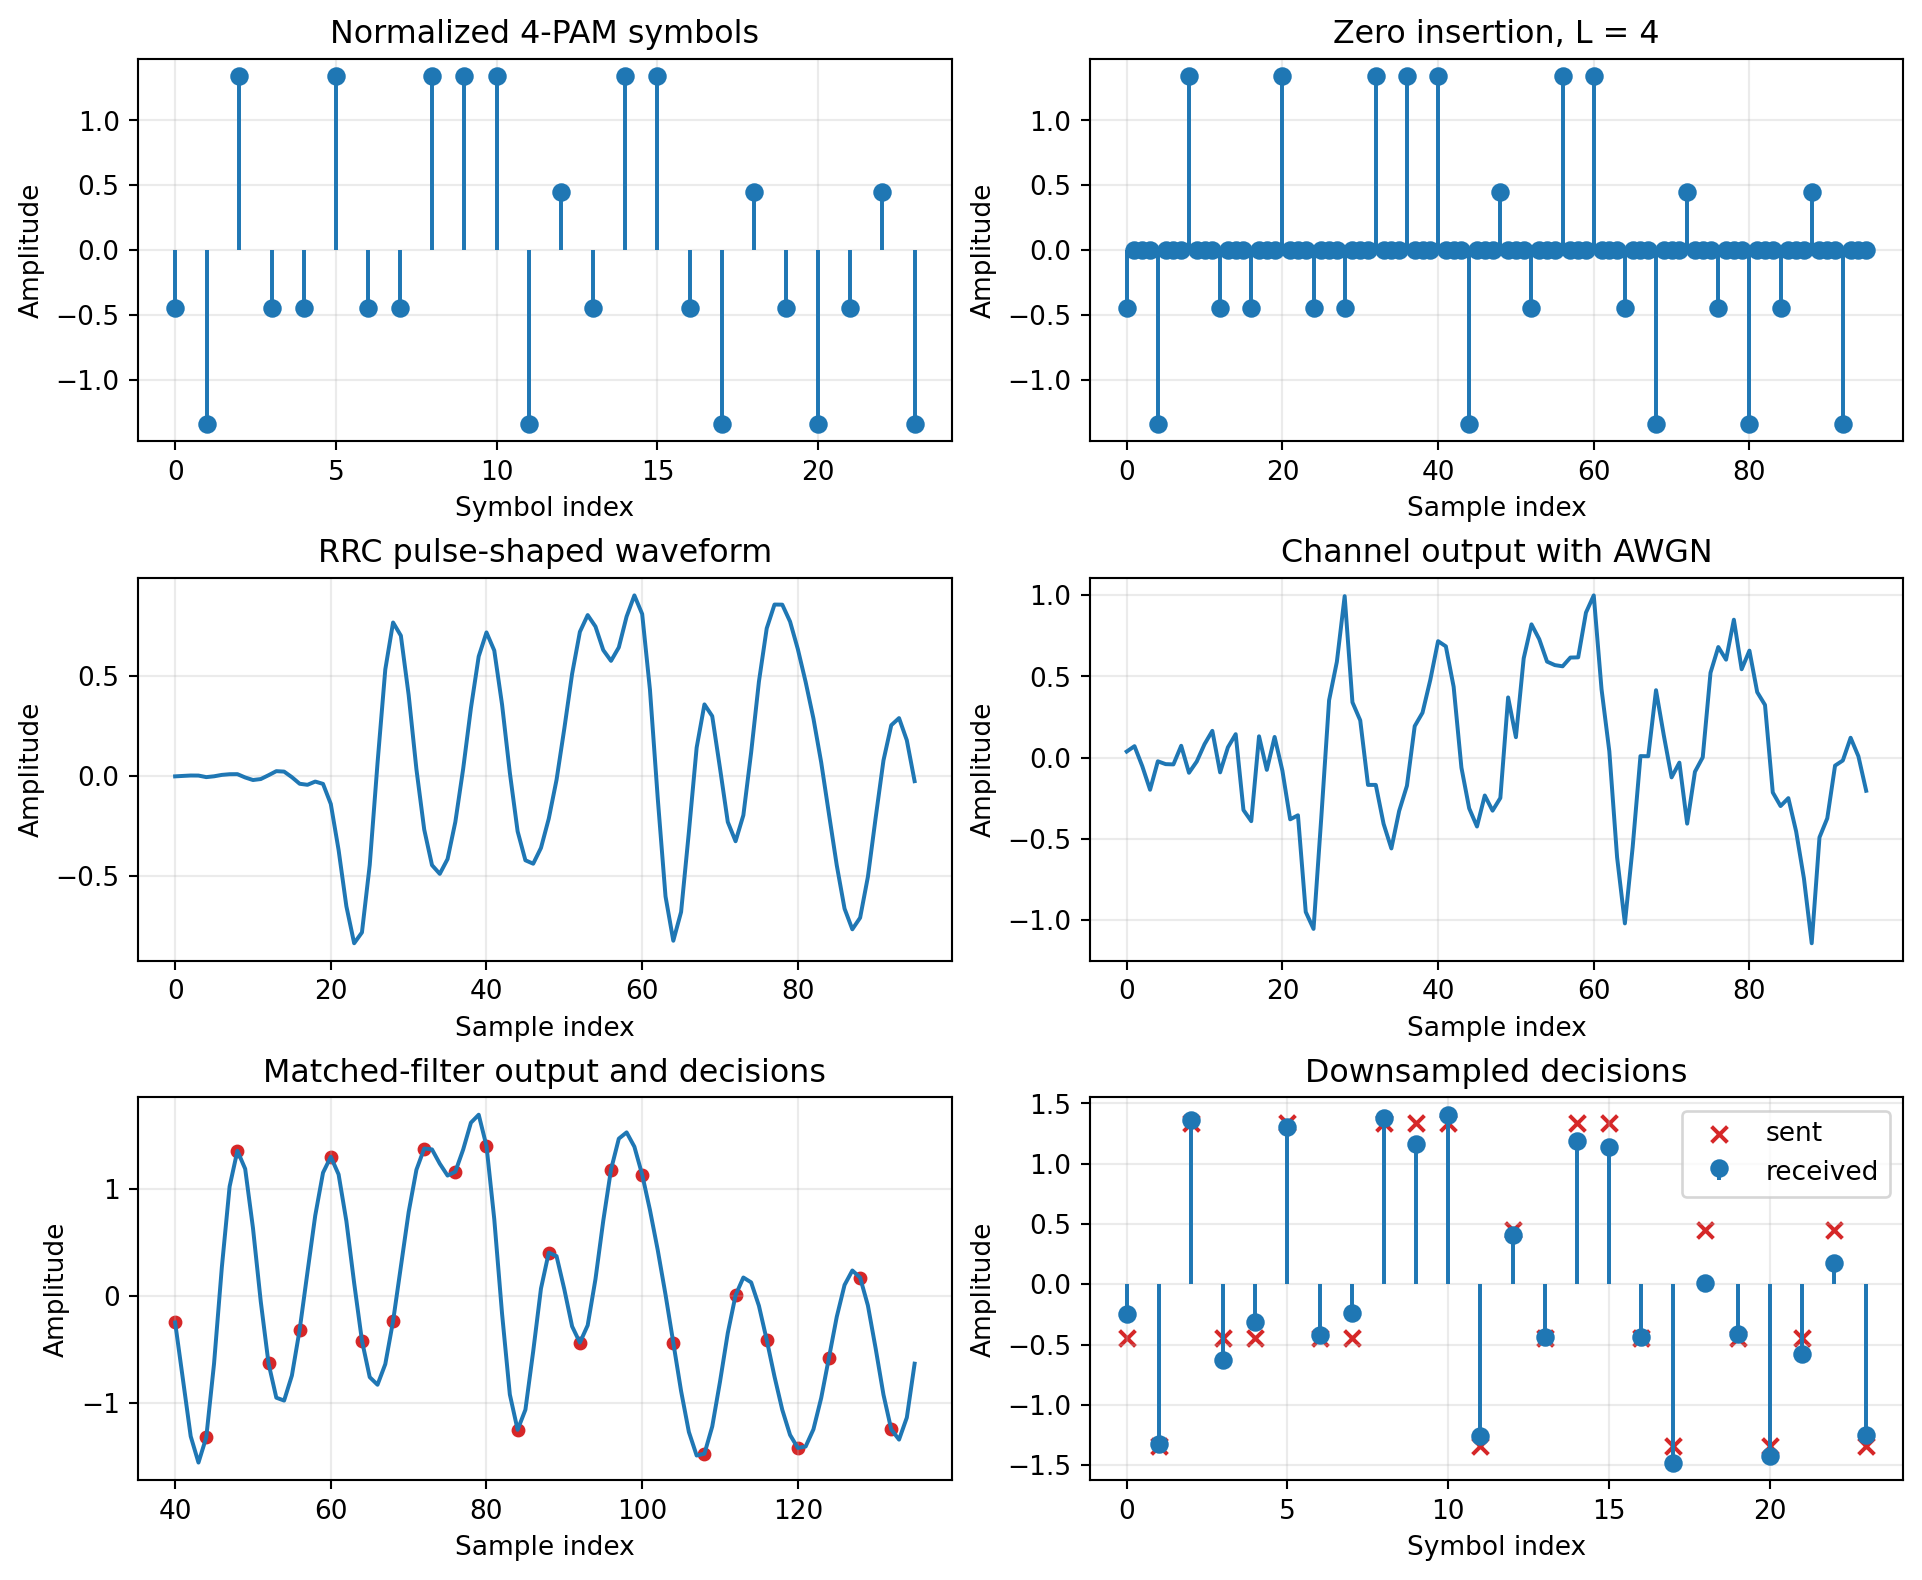

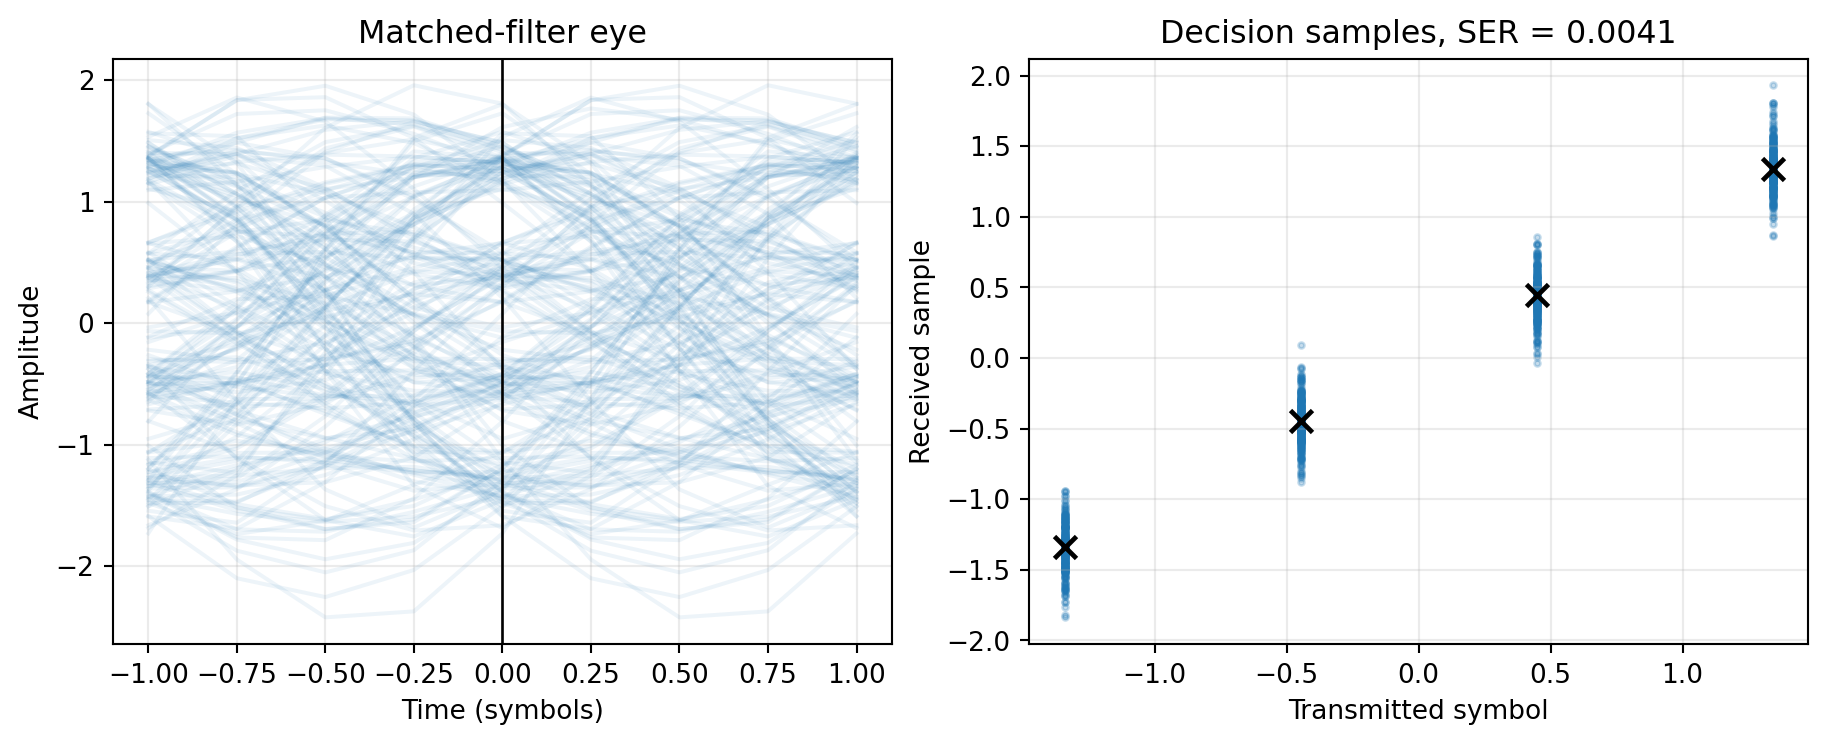

In [4]:
chain_figure = plot_pam_chain(
    symbols, upsampled, transmitted, received, matched,
    decision_indices, decisions, samples_per_symbol, FIGURE_DIR
)
eye_figure = plot_pam_eye(
    symbols, matched, decision_indices, decisions, levels,
    samples_per_symbol, ser, FIGURE_DIR
)
display(Image(filename=str(chain_figure)))
display(Image(filename=str(eye_figure)))

# Lab 3 Task 4: Multirate Processing of a Real N310 Capture

Generate the tone file, capture it with the same finite GRC flowgraphs, predict each alias, and compare raw downsampling with filtered resampling.

In [6]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

def locate_lab_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "support" / "lab3_tools.py").is_file():
            return base
    raise FileNotFoundError("Open this notebook from its Lab 3 folder.")

LAB_ROOT = locate_lab_root()
sys.path.insert(0, str(LAB_ROOT / "support"))
WORK_DIR = LAB_ROOT / "work"
FIGURE_DIR = WORK_DIR / "figures"
WAVEFORM_DIR = WORK_DIR / "waveforms"
CAPTURE_DIR = WORK_DIR / "captures"
for path in (FIGURE_DIR, WAVEFORM_DIR, CAPTURE_DIR):
    path.mkdir(parents=True, exist_ok=True)
print("Lab root:", LAB_ROOT)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Lab root: /Users/marcpham/jupyter_notebook_files/Embedded-Wireless-Design-Labs/Lab3


<span style="color:#165696"><b>Answer in the report.</b> Include the tone file calculation. For each output, calculate the sample rate, Nyquist interval, expected
alias, and measured spectral peak.</span>

In [7]:
from lab3_dsp import principal_alias
from lab3_tools import analyze_tone_capture, generate_tone_file, plot_task4_analysis

sample_rate_sps = 1_250_000
tone_hz = 100_000
tone_duration_s = 0.25
tone_amplitude = 0.10
transmit_seconds = 20.0
capture_seconds = 8.0

# to do: derive the output rates and predicted aliases.
rate_factor2_sps = sample_rate_sps // 2
rate_ratio7_10_sps = sample_rate_sps * 7 // 10
rate_factor20_sps = sample_rate_sps // 20
alias_factor2_hz = principal_alias(tone_hz, rate_factor2_sps)
alias_ratio7_10_hz = principal_alias(tone_hz, rate_ratio7_10_sps)
alias_factor20_hz = principal_alias(tone_hz, rate_factor20_sps)
tone_file_samples = int(sample_rate_sps * tone_duration_s)
tone_file_bytes = tone_file_samples * 8
capture_samples = int(sample_rate_sps * capture_seconds)
capture_bytes = capture_samples * 8

In [8]:
assert rate_factor2_sps == 625_000
assert rate_ratio7_10_sps == 875_000
assert rate_factor20_sps == 62_500
assert alias_factor2_hz == 100_000
assert alias_ratio7_10_hz == 100_000
assert alias_factor20_hz == -25_000
assert tone_file_samples == 312_500
assert tone_file_bytes == 2_500_000
assert capture_samples == 10_000_000
assert capture_bytes == 80_000_000
print("Rate, alias, and file-size calculations passed.")

Rate, alias, and file-size calculations passed.


In [16]:
report_df = pd.DataFrame({
    "Output": [
        "Factor-2 Decimation",
        "7/10 Resampling",
        "Raw Factor-20 Decimation",
        "Filtered Factor-20 Resampling"
    ],
    "Sample Rate (Hz)": [
        rate_factor2_sps,
        rate_ratio7_10_sps,
        rate_factor20_sps,
        rate_factor20_sps
    ],
    "Nyquist Frequency (Hz)": [
        rate_factor2_sps / 2,
        rate_ratio7_10_sps / 2,
        rate_factor20_sps / 2,
        rate_factor20_sps / 2
    ],"Nyquist Interval (s)": [
        1/(2*rate_factor2_sps),
        1/(2*rate_ratio7_10_sps),
        1/(2*rate_factor20_sps),
        1/(2*rate_factor20_sps)
    ],
    "Expected Alias (Hz)": [
        alias_factor2_hz,
        alias_ratio7_10_hz,
        alias_factor20_hz,
        "Suppressed"
    ],
    "Measured Peak (Hz)": [
        result["peaks_hz"]["Raw factor 2: 625 kS/s"],
        result["peaks_hz"]["Filtered ratio 7/10: 875 kS/s"],
        result["peaks_hz"]["Raw factor 20: 62.5 kS/s"],
        result["peaks_hz"]["Filtered factor 20: 62.5 kS/s"]
    ],
    "Peak Power (dB)": [
        result["powers_db"]["Raw factor 2: 625 kS/s"],
        result["powers_db"]["Filtered ratio 7/10: 875 kS/s"],
        result["powers_db"]["Raw factor 20: 62.5 kS/s"],
        result["powers_db"]["Filtered factor 20: 62.5 kS/s"]
    ]
})

display(report_df)

,Output,Sample Rate (Hz),Nyquist Frequency (Hz),Nyquist Interval (s),Expected Alias (Hz),Measured Peak (Hz),Peak Power (dB)
0,Factor-2 Decimation,625000,312500.0,8.000000e-07,100000.0,100097.656250,-21.859816
1,7/10 Resampling,875000,437500.0,5.714286e-07,100000.0,100082.397461,-21.856656
2,Raw Factor-20 Decimation,62500,31250.0,8.000000e-06,-25000.0,-24902.343750,-21.858690
3,Filtered Factor-20 Resampling,62500,31250.0,8.000000e-06,Suppressed,99.182129,-66.096088


<span style="color:#165696"><b>Answer in the report.</b>  Include the raw-versus-filtered factor-20 comparison. Explain why one path aliases and the other suppresses the tone. Explain why raw factor-20 downsampling produces a strong −25
kHz alias while filtered factor-20 resampling suppresses the original out-of-band tone.</span>

In the raw factor-20 downsampling path, the sample rate is reduced from 1.25 MS/s to 62.5 kS/s without first removing frequencies above the new Nyquist frequency of 31.25 kHz. Because the original 100 kHz tone lies outside this Nyquist range, it aliases into the passband and appears as a strong spectral peak at approximately −25 kHz. In contrast, the filtered factor-20 resampling path applies a low-pass anti-aliasing filter before decimation, removing the out-of-band 100 kHz tone before the sample rate is reduced. As a result, the tone cannot fold back into the spectrum, and the filtered output shows strong suppression of the original tone instead of a prominent alias.

<span style="color:#165696"><b>Answer in the report.</b> Include the GRC settings and exact capture size</span>  
With 312,500 samples, the expected capture size = 312,500 samples * 8 bytes per sample = 2,500,000 bytes.

In [9]:
tone_path = WAVEFORM_DIR / "task4_tone_tx_c64.dat"
tone = generate_tone_file(
    tone_path, sample_rate_sps, tone_hz, tone_duration_s, tone_amplitude
)
print(tone_path, tone_path.stat().st_size, "bytes", "peak", np.max(np.abs(tone)))

/Users/marcpham/jupyter_notebook_files/Embedded-Wireless-Design-Labs/Lab3/work/waveforms/task4_tone_tx_c64.dat 2500000 bytes peak 0.10000001


## GNU Radio capture sequence

For our GRC settings, we used the same two GRC files as Task 3. In the transmitter, select `task4_tone_tx_c64.dat`, use a 20.0-second Head, and keep 2.45 GHz and 1.25 MS/s. In the receiver, select `task4_tone_c64.dat` and use an 8.0-second Head. Start the transmitter first, then start the receiver. Confirm 10,000,000 complex64 samples and 80,000,000 bytes.

Original 1.25 MS/s                   peak   100.098 kHz, power  -21.860 dB
Raw factor 2: 625 kS/s               peak   100.098 kHz, power  -21.860 dB
Filtered ratio 7/10: 875 kS/s        peak   100.082 kHz, power  -21.857 dB
Raw factor 20: 62.5 kS/s             peak   -24.902 kHz, power  -21.859 dB
Filtered factor 20: 62.5 kS/s        peak     0.099 kHz, power  -66.096 dB


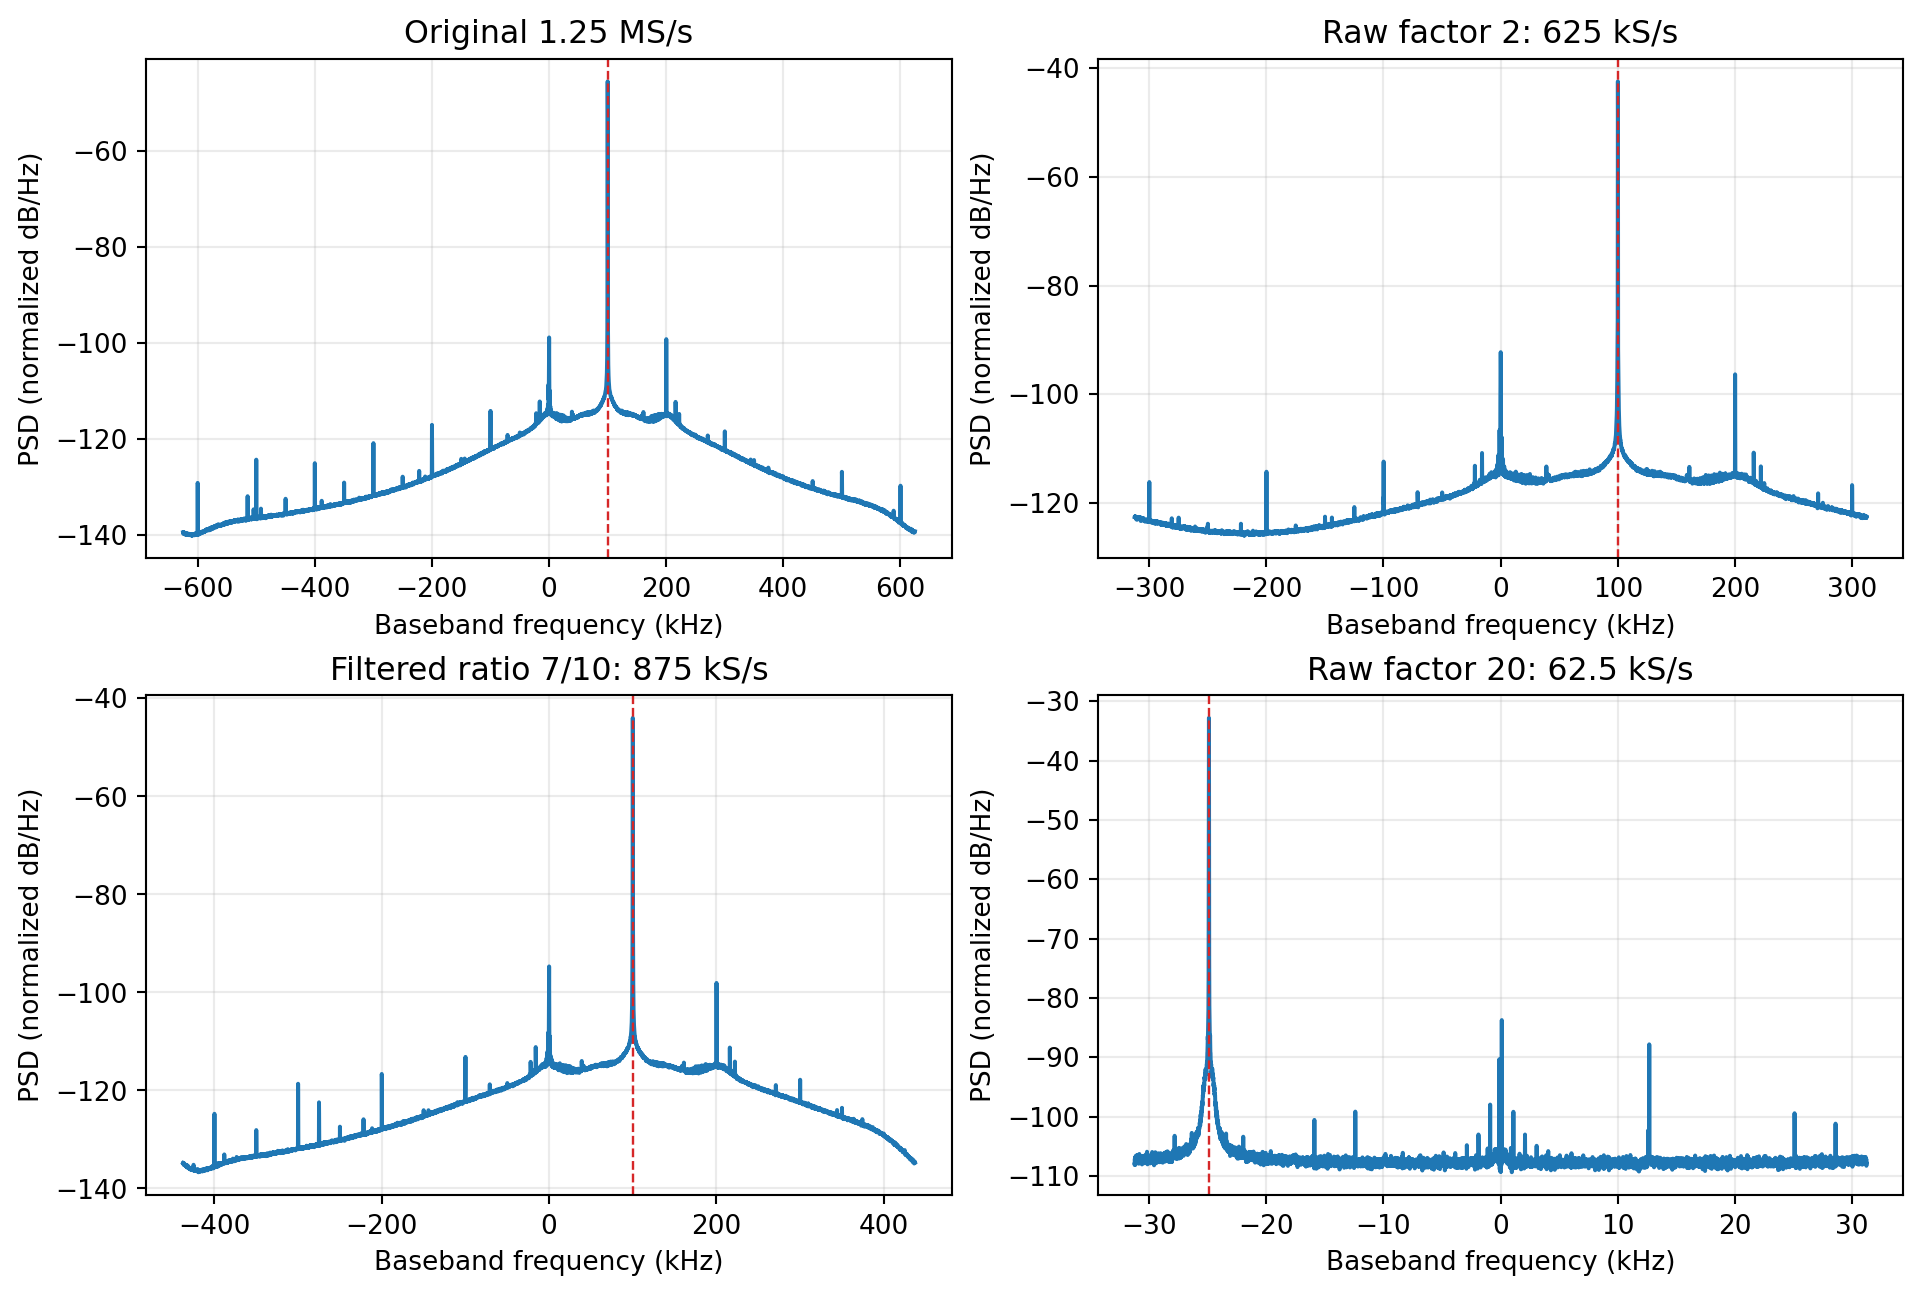

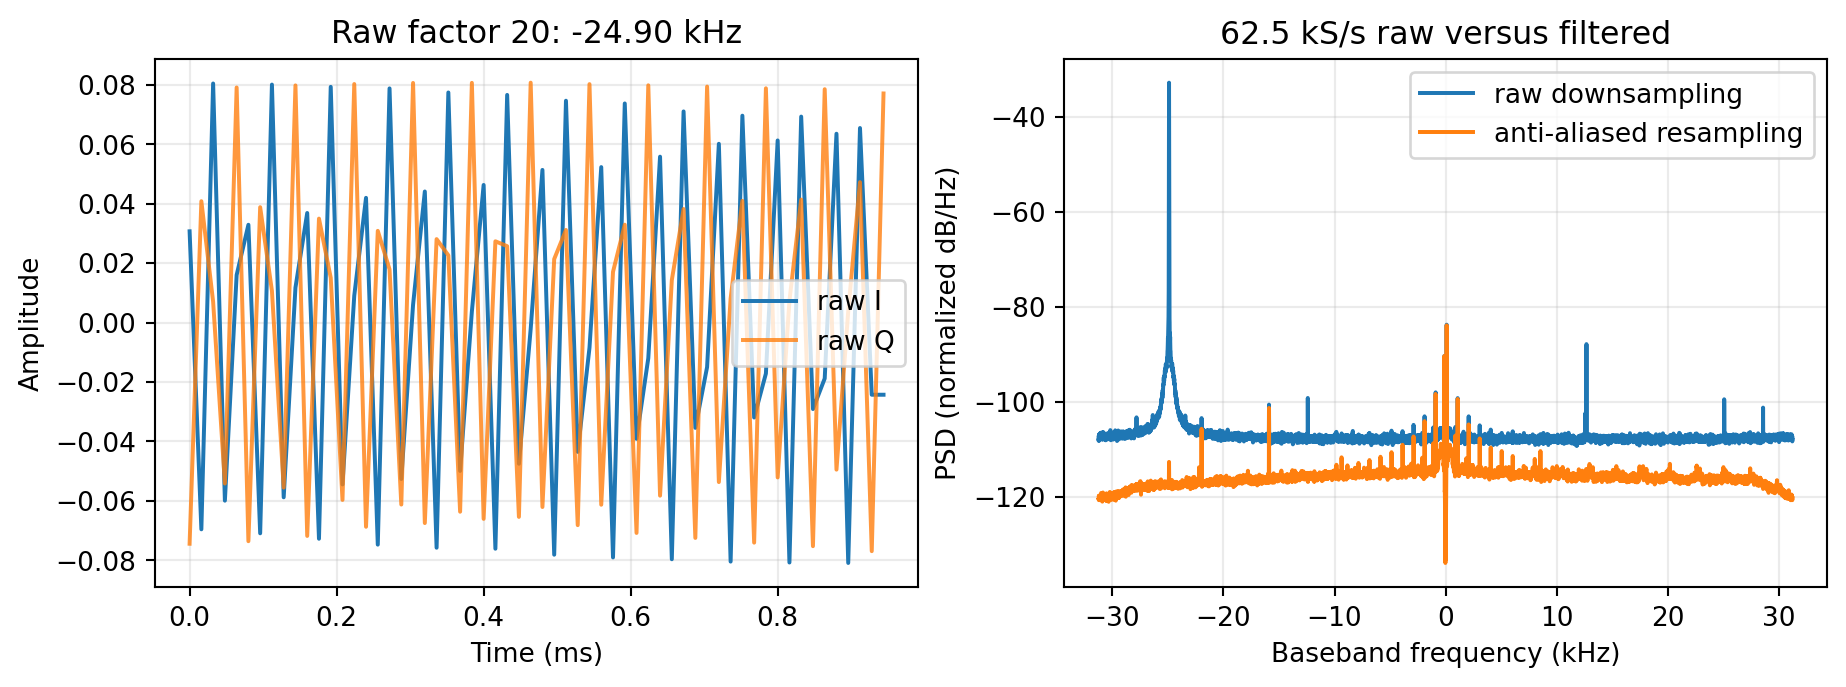

In [10]:
capture_path = CAPTURE_DIR / "task4_tone_c64.dat"
if not capture_path.is_file():
    raise FileNotFoundError("Capture task4_tone_c64.dat with GNU Radio before analysis.")
result = analyze_tone_capture(capture_path, sample_rate_sps, tone_hz)
for name, peak in result["peaks_hz"].items():
    print(f"{name:36s} peak {peak/1e3:9.3f} kHz, power {result['powers_db'][name]:8.3f} dB")
spectra_figure, alias_figure = plot_task4_analysis(result, FIGURE_DIR)
display(Image(filename=str(spectra_figure)))
display(Image(filename=str(alias_figure)))